# TF-IDF + Logistic Regression Baseline: 3-Class Text Classification

This notebook trains and evaluates a classical machine-learning baseline for classifying German text as Human, AI, or AI-assisted using TF-IDF features and Logistic Regression.

## Imports

This cell imports the libraries used for the logistic-regression baseline.

- `load_from_disk` loads the prepared Hugging Face dataset.
- `TfidfVectorizer` converts raw text into numerical TF-IDF features.
- `LogisticRegression` provides the classification model.
- The metrics are used to evaluate model performance.
- `NumPy` and `pandas` are used for numerical operations and result analysis.

Unlike the transformer models, this baseline does not learn contextual text representations. It classifies texts based on weighted word and n-gram features extracted with TF-IDF.

In [1]:
from datasets import load_from_disk

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)


import numpy as np
import pandas as pd

### Load the dataset

In [2]:
dataset = load_from_disk(
    "data/hf-dataset-3class-full"
)

dataset

DatasetDict({
    train: Dataset({
        features: ['id', 'file', 'text', 'label', 'language', 'split', 'source', 'source_name', 'source_type', 'document_type', 'title', 'document_id', 'target_length', 'actual_word_count', 'character_count', 'original_document_length', 'publication_date', 'date_basis', 'retrieval_date', 'license_name', 'license_url', 'source_url', 'hash', 'generator_provider', 'generator_model', 'seed_sample_id'],
        num_rows: 24986
    })
    validation: Dataset({
        features: ['id', 'file', 'text', 'label', 'language', 'split', 'source', 'source_name', 'source_type', 'document_type', 'title', 'document_id', 'target_length', 'actual_word_count', 'character_count', 'original_document_length', 'publication_date', 'date_basis', 'retrieval_date', 'license_name', 'license_url', 'source_url', 'hash', 'generator_provider', 'generator_model', 'seed_sample_id'],
        num_rows: 2906
    })
    test: Dataset({
        features: ['id', 'file', 'text', 'label', 'lan

## Prepare text and labels

This cell separates the raw text and class labels for the training, validation, and test splits.

- `X_train`, `X_val`, and `X_test` contain the texts.
- `y_train`, `y_val`, and `y_test` contain the corresponding class labels.

The cell also prints the number of samples in each split and checks the class distribution in the training set.

The training data is almost perfectly balanced across the three classes, which helps prevent the classifier from favoring one class simply because it appears more often.

In [3]:
X_train = dataset["train"]["text"]
y_train = dataset["train"]["label"]

X_val = dataset["validation"]["text"]
y_val = dataset["validation"]["label"]

X_test = dataset["test"]["text"]
y_test = dataset["test"]["label"]

print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

print("\nTrain label counts:")
print(pd.Series(y_train).value_counts().sort_index())

Train: 24986
Validation: 2906
Test: 2737

Train label counts:
0    8342
1    8324
2    8320
Name: count, dtype: int64


## Define the baseline pipeline and hyperparameter search

This cell builds the complete logistic-regression baseline.

The pipeline has two stages:

1. **TF-IDF vectorization** converts each text into numerical word and n-gram features.
2. **Logistic regression** uses those features to classify the text as Human, AI, or AI-assisted.

A grid search is used to test several combinations of TF-IDF and logistic-regression settings.

The parameters explored are:

- `min_df`: removes terms that occur in very few documents.
- `ngram_range`: compares single words with single words plus two-word combinations.
- `C`: controls the strength of regularization in logistic regression.

`StratifiedGroupKFold` performs three-fold cross-validation while preserving the class distribution and keeping texts from the same source document in the same fold. This helps reduce leakage between training and validation folds.

The best parameter combination is automatically selected based on validation accuracy.

In [4]:
X_train = list(dataset["train"]["text"])

y_train = np.asarray(
    dataset["train"]["label"],
    dtype=np.int64,
)

train_groups = np.asarray(
    dataset["train"]["document_id"],
    dtype=object,
)

print(f"Training samples: {len(dataset['train']):,}")
print(f"Source groups: {len(np.unique(train_groups)):,}")

Training samples: 24,986
Source groups: 3,356


In [5]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedGroupKFold,
)

RANDOM_STATE = 17

pipeline = Pipeline(
    [
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                max_df=0.98,
                max_features=200_000,
                sublinear_tf=True,
                dtype=np.float32,
            ),
        ),
        (
            "logreg",
            LogisticRegression(
                max_iter=1_000,
                random_state=RANDOM_STATE,
                solver="lbfgs",
            ),
        ),
    ]
)

param_grid = {
    "tfidf__min_df": [2, 5],
    "tfidf__ngram_range": [
        (1, 1),
        (1, 2),
    ],
    "logreg__C": [
        0.3,
        1.0,
        3.0,
    ],
}

cross_validation = StratifiedGroupKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE,
)

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="accuracy",
    cv=cross_validation,
    n_jobs=1,
    refit=True,
    return_train_score=False,
    verbose=2,
    error_score="raise",
)

In [6]:
grid_search.fit(
    X_train,
    y_train,
    groups=train_groups,
)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
[CV] END logreg__C=0.3, tfidf__min_df=2, tfidf__ngram_range=(1, 1); total time=  20.1s
[CV] END logreg__C=0.3, tfidf__min_df=2, tfidf__ngram_range=(1, 1); total time=  25.9s
[CV] END logreg__C=0.3, tfidf__min_df=2, tfidf__ngram_range=(1, 1); total time=  26.5s
[CV] END logreg__C=0.3, tfidf__min_df=2, tfidf__ngram_range=(1, 2); total time= 1.2min
[CV] END logreg__C=0.3, tfidf__min_df=2, tfidf__ngram_range=(1, 2); total time= 1.2min
[CV] END logreg__C=0.3, tfidf__min_df=2, tfidf__ngram_range=(1, 2); total time=  49.3s
[CV] END logreg__C=0.3, tfidf__min_df=5, tfidf__ngram_range=(1, 1); total time=  18.3s
[CV] END logreg__C=0.3, tfidf__min_df=5, tfidf__ngram_range=(1, 1); total time=  12.9s
[CV] END logreg__C=0.3, tfidf__min_df=5, tfidf__ngram_range=(1, 1); total time=  12.4s
[CV] END logreg__C=0.3, tfidf__min_df=5, tfidf__ngram_range=(1, 2); total time=  42.9s
[CV] END logreg__C=0.3, tfidf__min_df=5, tfidf__ngram_range=(1, 2); t

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=17))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'logreg__C': [0.3, 1.0, ...], 'tfidf__min_df': [2, 5], 'tfidf__ngram_range': [(1, ...), (1, ...)]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedGro... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"error_score error_score: 'raise' or numeric, default=np.nanValue to assign to the score if an error occurs in estimator fitting.If set to 'raise', the error is raised. If a numeric value is given,FitFailedWarning is raised. This parameter does not affect the refitstep, which will always raise the error.",'raise'
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSea

In [7]:
print("Best parameters:")
print(grid_search.best_params_)

print("\nBest CV accuracy:")
print(grid_search.best_score_)

Best parameters:
{'logreg__C': 3.0, 'tfidf__min_df': 5, 'tfidf__ngram_range': (1, 2)}

Best CV accuracy:
0.9095100283466587


## Inspect cross-validation results

This cell converts the results of the grid search into a pandas DataFrame and displays the most important hyperparameter combinations.

For each tested configuration, it shows:

- `param_tfidf__min_df` : minimum document frequency for a term to be included
- `param_tfidf__ngram_range` : whether the model uses only single words or also two-word combinations
- `param_logreg__C` : regularization strength of logistic regression
- `mean_test_score` : average cross-validation accuracy across the folds
- `std_test_score` : variation of the accuracy across the folds
- `rank_test_score` :  ranking of each configuration, where rank 1 is the best

The table is sorted by `rank_test_score`, so the best-performing configuration appears first.

In [8]:
cv_results = pd.DataFrame(
    grid_search.cv_results_
)

cv_results[
    [
        "param_tfidf__min_df",
        "param_tfidf__ngram_range",
        "param_logreg__C",
        "mean_test_score",
        "std_test_score",
        
        "rank_test_score",
    ]
].sort_values(
    "rank_test_score"
)

,param_tfidf__min_df,param_tfidf__ngram_range,param_logreg__C,mean_test_score,std_test_score,rank_test_score
11,5,"(1, 2)",3.0,0.909510,0.001732,1
9,2,"(1, 2)",3.0,0.909310,0.001821,2
7,5,"(1, 2)",1.0,0.906789,0.001897,3
5,2,"(1, 2)",1.0,0.906268,0.001662,4
10,5,"(1, 1)",3.0,0.903386,0.002739,5
8,2,"(1, 1)",3.0,0.901785,0.001898,6
6,5,"(1, 1)",1.0,0.901625,0.000694,7
4,2,"(1, 1)",1.0,0.898623,0.000379,8
2,5,"(1, 1)",0.3,0.892700,0.000007,9
3,5,"(1, 2)",0.3,0.892620,0.000959,10


## Evaluate the best model

Select the best model found during grid search and evaluate it on the validation and test sets using accuracy.

In [9]:
best_model = grid_search.best_estimator_

X_val = list(dataset["validation"]["text"])
y_val = np.asarray(
    dataset["validation"]["label"],
    dtype=np.int64,
)

X_test = list(dataset["test"]["text"])
y_test = np.asarray(
    dataset["test"]["label"],
    dtype=np.int64,
)

val_pred = best_model.predict(X_val)
test_pred = best_model.predict(X_test)

print("Validation accuracy:")
print(accuracy_score(y_val, val_pred))

print("\nTest accuracy:")
print(accuracy_score(y_test, test_pred))

Validation accuracy:
0.9146593255333793

Test accuracy:
0.9123127511874315


## Evaluate 3-class model performance

Evaluate the best 3-class model on the train, validation, and test sets using accuracy, Brier score, log loss, and confusion matrices for Human, AI, and AI-assisted text.

In [10]:
from sklearn.metrics import (
    accuracy_score,
    log_loss,
    confusion_matrix,
)
import numpy as np
import pandas as pd


def multiclass_brier_score(y_true, probabilities, n_classes=3):
    y_onehot = np.eye(n_classes)[y_true]

    return np.mean(
        np.sum(
            (probabilities - y_onehot) ** 2,
            axis=1,
        )
    )


def evaluate_split(split_name, split_dataset, model):

    y_true = np.asarray(
        split_dataset["label"],
        dtype=np.int64,
    )

    probabilities = model.predict_proba(
        split_dataset["text"]
    )

    y_pred = np.argmax(
        probabilities,
        axis=1,
    )

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1, 2],
    )

    return {
        "split": split_name,
        "accuracy": accuracy_score(
            y_true,
            y_pred,
        ),
        "brier_score": multiclass_brier_score(
            y_true,
            probabilities,
        ),
        "log_loss": log_loss(
            y_true,
            probabilities,
            labels=[0, 1, 2],
        ),
        "confusion_matrix": cm,
    }


evaluation = pd.DataFrame(
    [
        evaluate_split(
            "train",
            dataset["train"],
            best_model,
        ),
        evaluate_split(
            "validation",
            dataset["validation"],
            best_model,
        ),
        evaluate_split(
            "test",
            dataset["test"],
            best_model,
        ),
    ]
).set_index("split")


evaluation.style.format(
    {
        "accuracy": "{:.2%}",
        "brier_score": "{:.4f}",
        "log_loss": "{:.4f}",
    }
)

,accuracy,brier_score,log_loss,confusion_matrix
split,,,,
train,99.55%,0.0588,0.1616,[[8333 0 9] [ 1 8320 3] [ 98 1 8221]]
validation,91.47%,0.1438,0.2704,[[891 5 75] [ 6 927 34] [107 21 840]]
test,91.23%,0.1400,0.2666,[[836 11 67] [ 5 881 26] [112 19 780]]


## Confusion matrix

Visualize the test predictions for the three classes: Human, AI, and AI-assisted.

Rows represent the true labels and columns represent the model predictions. Correct predictions appear on the diagonal, while the off-diagonal cells show which classes are confused with each other.

This is especially useful in the 3-class setting because it shows whether the model mainly confuses AI-assisted text with Human or with fully AI-generated text.

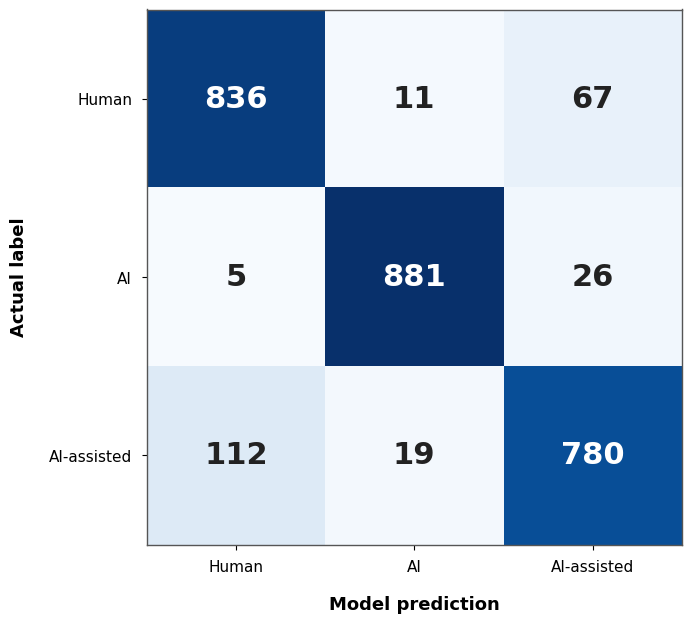

In [16]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix

y_test = np.asarray(
    dataset["test"]["label"],
    dtype=np.int64,
)

y_test_pred = best_model.predict(
    dataset["test"]["text"]
)

test_matrix = confusion_matrix(
    y_test,
    y_test_pred,
    labels=[0, 1, 2],
)

class_names = [
    "Human",
    "AI",
    "AI-assisted",
]

fig, ax = plt.subplots(figsize=(7, 7))

ax.imshow(
    test_matrix,
    cmap="Blues",
    vmin=0,
    vmax=test_matrix.max(),
)

for row in range(3):
    for column in range(3):

        value = test_matrix[row, column]

        text_color = (
            "white"
            if value > test_matrix.max() / 2
            else "#222222"
        )

        ax.text(
            column,
            row,
            f"{value:,}",
            ha="center",
            va="center",
            color=text_color,
            fontsize=22,
            fontweight="bold",
        )

ax.set_xticks(
    [0, 1, 2],
    labels=class_names,
)

ax.set_yticks(
    [0, 1, 2],
    labels=class_names,
)

ax.set_xlabel(
    "Model prediction",
    fontsize=13,
    fontweight="bold",
    labelpad=15,
)

ax.set_ylabel(
    "Actual label",
    fontsize=13,
    fontweight="bold",
    labelpad=15,
)

ax.tick_params(
    axis="both",
    labelsize=11,
    pad=7,
)

for spine in ax.spines.values():
    spine.set_color("#555555")
    spine.set_linewidth(1)

fig.tight_layout()

# save figure
plt.savefig(
    "tfidf-logreg-confmat-3class.svg",
    bbox_inches="tight",
)

# save confusion matrix as table
confmat_table = pd.DataFrame(
    test_matrix,
    index=[
        "Actual Human",
        "Actual AI",
        "Actual AI-assisted",
    ],
    columns=[
        "Predicted Human",
        "Predicted AI",
        "Predicted AI-assisted",
    ],
)

confmat_table.to_csv(
    "tfidf-logreg-confmat-3class.csv"
)

plt.show()

## Binary evaluation of the 3-class model

Evaluate the 3-class classifier only on Human (`0`) and AI (`1`) samples by excluding AI-assisted (`2`) texts.

Because the model still outputs three probabilities, the Human and AI probabilities are renormalized after removing the AI-assisted probability. The resulting binary probabilities are then used to calculate accuracy, Brier score, log loss, and the confusion-matrix counts.

In [12]:
from sklearn.metrics import (
    accuracy_score,
    brier_score_loss,
    log_loss,
    confusion_matrix,
)
import numpy as np
import pandas as pd


def evaluate_binary_split(split_name, split_dataset, model):

    # Keep only Human (0) and AI (1)
    labels = np.asarray(split_dataset["label"], dtype=np.int64)
    mask = labels != 2

    texts = np.asarray(split_dataset["text"], dtype=object)[mask]
    y_true = labels[mask]

    # Probabilities from the 3-class model
    probabilities = model.predict_proba(texts)

    human_prob = probabilities[:, 0]
    ai_prob = probabilities[:, 1]

    # Renormalize after removing AI-assisted probability
    total = human_prob + ai_prob
    ai_probability = ai_prob / total

    # Binary prediction
    y_pred = (ai_probability >= 0.5).astype(np.int64)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1],
    ).ravel()

    return {
        "split": split_name,
        "samples": len(y_true),
        "accuracy": accuracy_score(y_true, y_pred),
        "brier_score": brier_score_loss(
            y_true,
            ai_probability,
        ),
        "log_loss": log_loss(
            y_true,
            ai_probability,
            labels=[0, 1],
        ),
        "true_negative": tn,
        "false_positive": fp,
        "false_negative": fn,
        "true_positive": tp,
    }


binary_evaluation = pd.DataFrame(
    [
        evaluate_binary_split(
            "train",
            dataset["train"],
            best_model,
        ),
        evaluate_binary_split(
            "validation",
            dataset["validation"],
            best_model,
        ),
        evaluate_binary_split(
            "test",
            dataset["test"],
            best_model,
        ),
    ]
).set_index("split")


binary_evaluation.style.format(
    {
        "accuracy": "{:.2%}",
        "brier_score": "{:.4f}",
        "log_loss": "{:.4f}",
    }
)

,samples,accuracy,brier_score,log_loss,true_negative,false_positive,false_negative,true_positive
split,,,,,,,,
train,16666,99.99%,0.0024,0.0265,8342,0,1,8323
validation,1938,98.92%,0.0107,0.0523,962,9,12,955
test,1826,98.96%,0.0104,0.0503,901,13,6,906


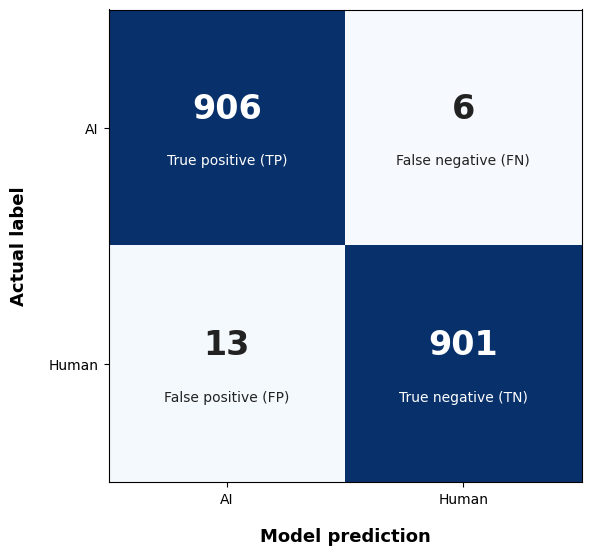

,Predicted AI,Predicted Human
Actual AI,906,6
Actual Human,13,901


Download figure:


/Users/hassanhijazi/Desktop/Ai_Detector/tfidf-logreg-confmat-human-ai.svg

Download table:


/Users/hassanhijazi/Desktop/Ai_Detector/tfidf-logreg-confmat-human-ai.csv

In [29]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.metrics import confusion_matrix
from IPython.display import display, FileLink


# ============================================================
# TEST SET: KEEP HUMAN (0) AND AI (1)
# ============================================================

labels = np.asarray(
    dataset["test"]["label"],
    dtype=np.int64,
)

mask = labels != 2

texts = np.asarray(
    dataset["test"]["text"],
    dtype=object,
)[mask]

y_true = labels[mask]


# ============================================================
# MODEL PROBABILITIES
# ============================================================

probabilities = best_model.predict_proba(
    texts
)

human_prob = probabilities[:, 0]
ai_prob = probabilities[:, 1]


# ============================================================
# RENORMALIZE HUMAN VS AI
# ============================================================

ai_probability = (
    ai_prob
    / (human_prob + ai_prob)
)


# ============================================================
# BINARY PREDICTION
# ============================================================

y_pred = (
    ai_probability >= 0.5
).astype(np.int64)


# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[1, 0],
)


# ============================================================
# CREATE FIGURE
# ============================================================

fig, ax = plt.subplots(
    figsize=(6, 6)
)

ax.imshow(
    cm,
    cmap="Blues",
    vmin=0,
    vmax=cm.max(),
)

cell_labels = np.array(
    [
        [
            "True positive (TP)",
            "False negative (FN)",
        ],
        [
            "False positive (FP)",
            "True negative (TN)",
        ],
    ]
)

for row in range(2):
    for column in range(2):

        value = cm[row, column]

        text_color = (
            "white"
            if value > cm.max() / 2
            else "#222222"
        )

        ax.text(
            column,
            row - 0.08,
            f"{value:,}",
            ha="center",
            va="center",
            color=text_color,
            fontsize=24,
            fontweight="bold",
        )

        ax.text(
            column,
            row + 0.14,
            cell_labels[row, column],
            ha="center",
            va="center",
            color=text_color,
            fontsize=10,
        )

ax.set_xticks(
    [0, 1],
    labels=[
        "AI",
        "Human",
    ],
)

ax.set_yticks(
    [0, 1],
    labels=[
        "AI",
        "Human",
    ],
)

ax.set_xlabel(
    "Model prediction",
    fontsize=13,
    fontweight="bold",
    labelpad=15,
)

ax.set_ylabel(
    "Actual label",
    fontsize=13,
    fontweight="bold",
    labelpad=15,
)

fig.tight_layout()


# ============================================================
# SAVE FIGURE
# ============================================================

svg_file = (
    "tfidf-logreg-confmat-human-ai.svg"
)

plt.savefig(
    svg_file,
    bbox_inches="tight",
)


# ============================================================
# SAVE CONFUSION MATRIX TABLE
# ============================================================

confmat_binary_table = pd.DataFrame(
    cm,
    index=[
        "Actual AI",
        "Actual Human",
    ],
    columns=[
        "Predicted AI",
        "Predicted Human",
    ],
)

csv_file = (
    "tfidf-logreg-confmat-human-ai.csv"
)

confmat_binary_table.to_csv(
    csv_file
)


# ============================================================
# SHOW FIGURE + TABLE
# ============================================================

plt.show()

display(
    confmat_binary_table
)


# ============================================================
# DOWNLOAD LINKS
# ============================================================

print("Download figure:")
display(
    FileLink(svg_file)
)

print("Download table:")
display(
    FileLink(csv_file)
)

## Save model artifacts

Save the trained 3-class TF-IDF + Logistic Regression model together with its metadata, including the label mapping, best hyperparameters, evaluation scores, and package versions.

In [19]:
from pathlib import Path
from joblib import dump
from importlib.metadata import version
import platform
import json

ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

MODEL_PATH = ARTIFACT_DIR / "tfidf-logreg-3class.joblib"
METADATA_PATH = ARTIFACT_DIR / "tfidf-logreg-3class.json"

dump(
    best_model,
    MODEL_PATH,
    compress=3,
)

metadata = {
    "dataset": "data/hf-dataset-3class-full",

    "label_mapping": {
        "human": 0,
        "ai": 1,
        "ai_assisted": 2,
    },

    "model_type": "TF-IDF + Logistic Regression",

    "best_parameters": grid_search.best_params_,

    "cross_validation_accuracy": float(
        grid_search.best_score_
    ),

    "validation_accuracy": float(
        accuracy_score(
            y_val,
            val_pred,
        )
    ),

    "test_accuracy": float(
        accuracy_score(
            y_test,
            test_pred,
        )
    ),

    "python_version": platform.python_version(),

    "package_versions": {
        package: version(package)
        for package in [
            "datasets",
            "joblib",
            "numpy",
            "scikit-learn",
        ]
    },
}

METADATA_PATH.write_text(
    json.dumps(
        metadata,
        indent=2,
    ) + "\n",
    encoding="utf-8",
)

print(f"Saved model to {MODEL_PATH}")
print(f"Saved metadata to {METADATA_PATH}")

Saved model to artifacts/tfidf-logreg-3class.joblib
Saved metadata to artifacts/tfidf-logreg-3class.json


## Run inference on new text

Load the saved 3-class model and classify new text as Human, AI, or AI-assisted.

The model also returns the predicted probability for each of the three classes.

In [20]:
from joblib import load
import numpy as np

loaded_model = load(
    "artifacts/tfidf-logreg-3class.joblib"
)

texts = [
    "Dieses Projekt fokussiert die Entwicklung eines robusten Klassifikationssystems zur automatisierten Unterscheidung deutschsprachiger Texte in die Kategorien Human, AI und AI-assisted. Grundlage ist ein strukturierter Datensatz, auf dessen Basis sowohl klassische Machine-Learning-Verfahren als auch moderne Transformer-Modelle evaluiert werden. Die Leistungsbewertung erfolgt auf getrennten Trainings-, Validierungs- und Testdaten anhand geeigneter Klassifikationsmetriken, Konfusionsmatrizen und Lernkurven. Ergänzend werden mögliche Verzerrungen, etwa durch die Textlänge, sowie die Kalibrierung der Modellwahrscheinlichkeiten untersucht. Ziel ist ein zuverlässiger, reproduzierbarer und methodisch nachvollziehbarer Detektor für menschlich verfasste, KI-generierte und KI-unterstützte Texte."
]

probabilities = loaded_model.predict_proba(texts)
predictions = loaded_model.predict(texts)

label_mapping = {
    0: "Human",
    1: "AI",
    2: "AI-assisted",
}

for text, probs, prediction in zip(
    texts,
    probabilities,
    predictions,
):
    label = label_mapping[prediction]

    print(f"Prediction: {label}")
    print(f"Human:       {probs[0]:.1%}")
    print(f"AI:          {probs[1]:.1%}")
    print(f"AI-assisted: {probs[2]:.1%}")
    print(f"\n{text}")

Prediction: AI
Human:       12.8%
AI:          65.1%
AI-assisted: 22.1%

Dieses Projekt fokussiert die Entwicklung eines robusten Klassifikationssystems zur automatisierten Unterscheidung deutschsprachiger Texte in die Kategorien Human, AI und AI-assisted. Grundlage ist ein strukturierter Datensatz, auf dessen Basis sowohl klassische Machine-Learning-Verfahren als auch moderne Transformer-Modelle evaluiert werden. Die Leistungsbewertung erfolgt auf getrennten Trainings-, Validierungs- und Testdaten anhand geeigneter Klassifikationsmetriken, Konfusionsmatrizen und Lernkurven. Ergänzend werden mögliche Verzerrungen, etwa durch die Textlänge, sowie die Kalibrierung der Modellwahrscheinlichkeiten untersucht. Ziel ist ein zuverlässiger, reproduzierbarer und methodisch nachvollziehbarer Detektor für menschlich verfasste, KI-generierte und KI-unterstützte Texte.


### Length-bias analysis

Evaluate TF-IDF + Logistic Regression performance across different text-length ranges to check whether classification quality changes for shorter or longer samples. For each length bin, report class counts, accuracy, mean class confidence, and class-specific error rates.

In [21]:
y_test = np.asarray(
    dataset["test"]["label"],
    dtype=np.int64,
)

texts = np.asarray(
    dataset["test"]["text"],
    dtype=object,
)

test_probabilities = best_model.predict_proba(
    texts
)

y_test_pred = np.argmax(
    test_probabilities,
    axis=1,
)

word_lengths = np.asarray([
    len(text.split())
    for text in texts
])

length_bins = [
    (0, 70, "≤70"),
    (71, 150, "71–150"),
    (151, 300, "151–300"),
    (301, 500, "301–500"),
    (501, 750, "501–750"),
    (751, np.inf, "750+"),
]

rows = []

for lower, upper, name in length_bins:
    bin_mask = (
        (word_lengths >= lower)
        & (word_lengths <= upper)
    )

    y_bin = y_test[bin_mask]
    pred_bin = y_test_pred[bin_mask]
    probabilities_bin = test_probabilities[
        bin_mask
    ]

    if len(y_bin) == 0:
        continue

    human_mask = y_bin == 0
    ai_mask = y_bin == 1
    ai_assisted_mask = y_bin == 2

    mean_human_score = (
        probabilities_bin[
            human_mask,
            0
        ].mean() * 100
    )

    mean_ai_score = (
        probabilities_bin[
            ai_mask,
            1
        ].mean() * 100
    )

    mean_ai_assisted_score = (
        probabilities_bin[
            ai_assisted_mask,
            2
        ].mean() * 100
    )

    human_error_rate = np.mean(
        pred_bin[human_mask] != 0
    )

    ai_error_rate = np.mean(
        pred_bin[ai_mask] != 1
    )

    ai_assisted_error_rate = np.mean(
        pred_bin[ai_assisted_mask] != 2
    )

    rows.append(
        {
            "model": "TF-IDF + Logistic Regression",
            "length_bin": name,
            "samples": len(y_bin),
            "human_samples": human_mask.sum(),
            "ai_samples": ai_mask.sum(),
            "ai_assisted_samples": ai_assisted_mask.sum(),
            "accuracy": accuracy_score(
                y_bin,
                pred_bin,
            ),
            "mean_human_score": mean_human_score,
            "mean_ai_score": mean_ai_score,
            "mean_ai_assisted_score": mean_ai_assisted_score,
            "human_error_rate": human_error_rate,
            "ai_error_rate": ai_error_rate,
            "ai_assisted_error_rate": ai_assisted_error_rate,
        }
    )

logreg_length_results_3class = pd.DataFrame(
    rows
)

logreg_length_results_3class

,model,length_bin,samples,human_samples,ai_samples,ai_assisted_samples,accuracy,mean_human_score,mean_ai_score,mean_ai_assisted_score,human_error_rate,ai_error_rate,ai_assisted_error_rate
0,TF-IDF + Logistic Regression,≤70,399,134,134,131,0.769424,65.544243,72.485939,53.230446,0.194030,0.111940,0.389313
1,TF-IDF + Logistic Regression,71–150,293,94,122,77,0.918089,78.667542,86.546173,64.352638,0.095745,0.024590,0.155844
2,TF-IDF + Logistic Regression,151–300,640,207,245,188,0.929688,78.888130,89.214081,74.202797,0.077295,0.028571,0.117021
3,TF-IDF + Logistic Regression,301–500,342,106,89,147,0.947368,81.821899,90.504082,80.180412,0.047170,0.033708,0.068027
4,TF-IDF + Logistic Regression,501–750,653,233,191,229,0.941807,84.119835,94.573875,80.845299,0.055794,0.015707,0.096070
5,TF-IDF + Logistic Regression,750+,410,140,131,139,0.943902,85.905052,95.824554,82.308098,0.064286,0.000000,0.100719


In [28]:
logreg_length_results_3class.to_csv(
    "tfidf-logreg-length-bias-3class.csv",
    index=False,
)